In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from itertools import product

import missingno

In [46]:
data_subset = pd.read_pickle('data/maize-subset-clean.pkl')
data_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917 entries, 0 to 3753
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   prodkgha                 1917 non-null   float64
 1   weedings                 1917 non-null   float64
 2   soilclay                 1917 non-null   float64
 3   soilsand                 1917 non-null   float64
 4   soildensity              1917 non-null   float64
 5   soilcec                  1917 non-null   float64
 6   soilph                   1917 non-null   float64
 7   soiloc                   1917 non-null   float64
 8   wthtmean                 1917 non-null   float32
 9   wthsrad                  1917 non-null   float32
 10  wthprec                  1917 non-null   float32
 11  wthrainydays             1917 non-null   float64
 12  wthmaxdryspell           1917 non-null   int64  
 13  previousadvice           1917 non-null   bool   
 14  genderfemale             1917

# Causal model

In [47]:
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator
from dowhy import CausalModel

Even though we would like to include all the variables, including them all would cause to have many edges, and this would cause the effect identification take forever. Therefore, we will reduce the number of variables in the model.

In [48]:
# Soil variables
data_subset = data_subset.rename(columns={
    'soiloc': 'spfoc', 'soilcec': 'srfcec',
    'soilclay': 'sppclay', 'soilsand': 'sppsand', 'soildensity': 'sppdensity'
})
spf_vars = ['spfoc'] # Soil potential fertility
srf_vars = ['srfcec'] # Soil response to fertilizer
spp_vars = ['sppclay', 'sppsand', 'sppdensity'] # Soil physical properties

In [49]:
# Weather
wth_vars = [
    'wthtmean', 'wthprec', 'wthsrad'
    # 'wthsrad', 'wthrainydays', 'wthmaxdryspell'
]
# Fertilizer
fert_vars = [
    'fertbasal', 'fert56leaves', 'fertkneehigh', 'fert810leaves', 
    'fertemergence', 'ferttasseling', 'fertsilking'
]
data_subset['ferttotal'] = data_subset[fert_vars].sum(axis=1)
fert_vars = ['ferttotal']
# Varieties
variety_vars = [
    'vardk777', 'vardkc9089', 'varlocalvariety', 'varmeruhb513', 
    'varpan53', 'varpan691', 'varsc403', 'varsc627', 'varsc719', 
    'varuh615', 'varuh6303', 'varzms606'
]
# Field history
history_vars = [
    'histmaize', 'histnocrop', 'histlegume', 'histoilseed', 
    # 'histrootandtuber'
]
# Residue
residue_vars = ['resburn', 'resfeedtoanimals', 'resincorporateinthesoil', 'resleaveonfield']
data_subset['resonfield'] =  data_subset[['resincorporateinthesoil', 'resleaveonfield']].any(axis=1)
residue_vars = ['resonfield']
# Technology access
tech_vars = ['techhandhoe', 'techploughcattle', 'techtractor']
# Herbicide
herb_vars = ['herbicidepost', 'herbicidepre']
data_subset['herbicide'] = data_subset[herb_vars].any(axis=1)
herb_vars = ['herbicide']

In [222]:
# Define all the edges
edges_list = []
############################
##    Edges Out of Soil   ##
############################
# Soil CEC -> Nutrient uptake
edges_list.extend([(v, 'nucrop') for v in srf_vars])
# SOC -> Nutrient uptake
edges_list.extend([(v, 'nucrop') for v in spf_vars])
# SOC -> Fertilizer
edges_list.extend([(vs, vf) for vs, vf in zip(spf_vars, fert_vars)])
# Soil Physical Props -> Soil Moisture
edges_list.extend([(v, 'smoist') for v in spp_vars])
# Soil -> Advice
edges_list.extend([(v, 'previousadvice') for v in spp_vars+spf_vars+srf_vars])

############################
##  Edges Out of Weather  ##
############################
# Rain -> Soil Moisture
edges_list.extend([('wthprec', 'smoist')])
# Temperature, Srad -> Crop G&D
edges_list.extend([('wthtmean', 'gdcrop'), ('wthsrad', 'gdcrop')])
# Soil Moisture -> Water uptake
edges_list.extend([('smoist', 'wucrop')])
# Soil Moisture -> Nutrient uptake
edges_list.extend([('smoist', 'nucrop')])
# Weather -> Pest and diseases
edges_list.extend([(v, 'pestdisease') for v in wth_vars])
# Weather -> Advice
edges_list.extend([(v, 'previousadvice') for v in ('wthprec', 'wthtmean')])

############################
## Edges Out of Crop G&D  ##
############################
edges_list.extend([('gdcrop', 'prodkgha')])

#####################################
## Edges Out of N. and Wat. Uptake ##
#####################################
edges_list.extend([('wucrop', 'gdcrop')])
edges_list.extend([('nucrop', 'gdcrop')])

#############################
## Edges Out of Management ##
#############################
# Variety -> Pest and Diseases
edges_list.extend([(v, 'pestdisease') for v in variety_vars])
# Variety -> Crop G&D
edges_list.extend([(v, 'gdcrop') for v in variety_vars])
# Residue -> Nutrient uptake
edges_list.extend([(v, 'nucrop') for v in residue_vars])
# Residue -> Soil moisture
edges_list.extend([(v, 'smoist') for v in residue_vars])
# Herbicide -> Crop G&D 
edges_list.extend([(v, 'gdcrop') for v in herb_vars])
# Herbicide -> Weeding
edges_list.extend([(v, 'weedings') for v in herb_vars])
# Weeding -> Crop G&D
edges_list.extend([('weedings', 'gdcrop')]) 
# Fertilizer -> Nutrient uptake
edges_list.extend([(v, 'nucrop') for v in fert_vars])
# Pest and diseases -> Crop G&D
edges_list.extend([('pestdisease', 'gdcrop')])

####################################
## Edges Out of Technology Access ##
####################################
# Technology -> Fertilizer
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, fert_vars)])
# Technology -> Variety
edges_list.extend([(vt, vv) for vt, vv in product(tech_vars, variety_vars)])
# Technology -> Herbicide
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, herb_vars)])
# Technology -> Pest and diseases
edges_list.extend([(v, 'pestdisease') for v in tech_vars])
# Technology -> Advice
edges_list.extend([(v, 'previousadvice') for v in tech_vars])
# Technology -> History
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, history_vars)])

#########################
## Edges Out of Gender ##
#########################
# Gender -> Technology
edges_list.extend([('genderfemale', v) for v in tech_vars])
# Gender -> Land size
edges_list.extend([('genderfemale', 'fieldsize')]) 
# Gender -> History
edges_list.extend([('genderfemale', v) for v in history_vars])
# Gender -> Advice
edges_list.extend([('genderfemale', 'previousadvice')]) 

############################
## Edges Out of Land Size ##
############################
# Land size -> Technology
edges_list.extend([('fieldsize', v) for v in tech_vars])
# Land size -> Weeding
edges_list.extend([('fieldsize', 'weedings')]) 
# Land size -> Advice
edges_list.extend([('fieldsize', 'previousadvice')]) 

###############################
## Edges Out of Land History ##
###############################
# History -> Pest and diseases
edges_list.extend([(v, 'pestdisease') for v in history_vars])
# History -> Soil Moisture
edges_list.extend([(v, 'smoist') for v in history_vars])
# History -> Nutrient uptake
edges_list.extend([(v, 'nucrop') for v in history_vars])
# History -> Advice
edges_list.extend([(v, 'previousadvice') for v in history_vars])
# History -> Residue
edges_list.extend([(vh, vr) for vh, vr in zip(history_vars, residue_vars)])
# History -> Fertilizer
edges_list.extend([(vh, vf) for vh, vf in zip(history_vars, fert_vars)])

##############################
## Edges Out of Prev Advice ##
##############################
# Advice -> Management
edges_list.extend([('previousadvice', v) for v in residue_vars])
edges_list.extend([('previousadvice', v) for v in fert_vars])
edges_list.extend([('previousadvice', v) for v in variety_vars])
edges_list.extend([('previousadvice', v) for v in herb_vars])
edges_list.extend([('previousadvice', 'weedings')]) 
edges_list.extend([('previousadvice', 'pestdisease')])

In [223]:
edges_list

[('srfcec', 'nucrop'),
 ('spfoc', 'nucrop'),
 ('spfoc', 'ferttotal'),
 ('sppclay', 'smoist'),
 ('sppsand', 'smoist'),
 ('sppdensity', 'smoist'),
 ('sppclay', 'previousadvice'),
 ('sppsand', 'previousadvice'),
 ('sppdensity', 'previousadvice'),
 ('spfoc', 'previousadvice'),
 ('srfcec', 'previousadvice'),
 ('wthprec', 'smoist'),
 ('wthtmean', 'gdcrop'),
 ('wthsrad', 'gdcrop'),
 ('smoist', 'wucrop'),
 ('smoist', 'nucrop'),
 ('wthtmean', 'pestdisease'),
 ('wthprec', 'pestdisease'),
 ('wthsrad', 'pestdisease'),
 ('wthprec', 'previousadvice'),
 ('wthtmean', 'previousadvice'),
 ('gdcrop', 'prodkgha'),
 ('wucrop', 'gdcrop'),
 ('nucrop', 'gdcrop'),
 ('vardk777', 'pestdisease'),
 ('vardkc9089', 'pestdisease'),
 ('varlocalvariety', 'pestdisease'),
 ('varmeruhb513', 'pestdisease'),
 ('varpan53', 'pestdisease'),
 ('varpan691', 'pestdisease'),
 ('varsc403', 'pestdisease'),
 ('varsc627', 'pestdisease'),
 ('varsc719', 'pestdisease'),
 ('varuh615', 'pestdisease'),
 ('varuh6303', 'pestdisease'),
 ('varz

In [224]:
causal_graph = nx.DiGraph(edges_list)
# As some factors are represented by multiple variables (e.g. Variety), 
# we will create a simplified graph that will be the one used when drawing.
graph_to_draw = nx.DiGraph({(cause[:3], effect[:3]) for cause, effect in edges_list})

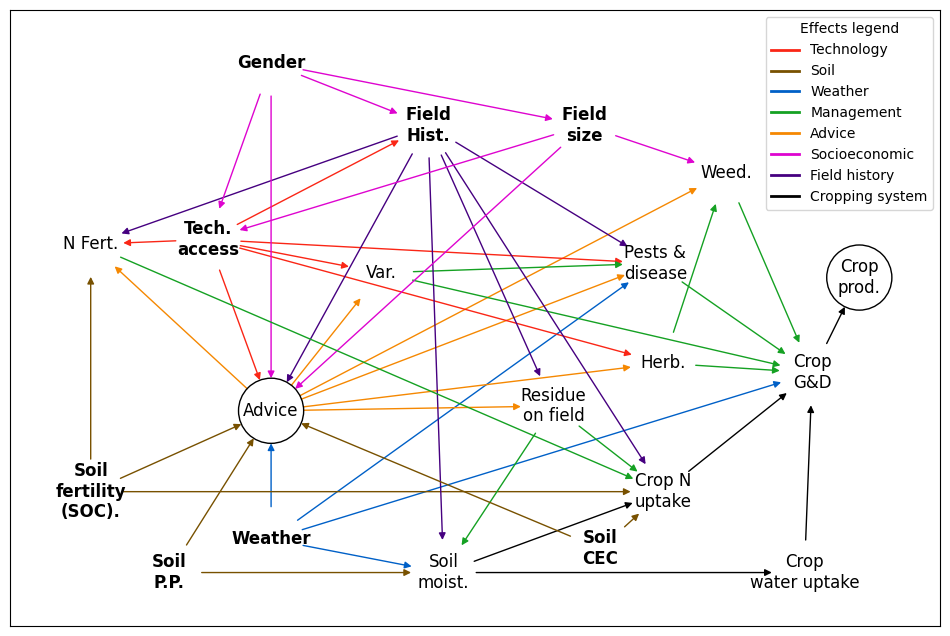

In [254]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels={
    'her': 'Herb.', 'wee': 'Weed.', 'gdc': 'Crop\nG&D',
    'wth': 'Weather', 'smo': 'Soil\nmoist.', 'spf': 'Soil\nfertility\n(SOC).',
    'pre': 'Advice', 'tec': 'Tech.\naccess', 'var': 'Var.', 
    'his': 'Field\nHist.', 'pes': 'Pests &\ndisease', 'res': 'Residue\non field',
    'gen': 'Gender', 'nuc': 'Crop N\nuptake', 'fie': 'Field\nsize',
    'fer': 'N Fert.', 'pro': 'Crop\nprod.', 'wuc': 'Crop\nwater uptake',
    'srf': 'Soil\nCEC', 'spp': 'Soil\nP.P.',
}
pos={
    'her': (1., 0.2), 'wee': (1.8, 4.2), 'gdc': (2.9, 0),
    'wth': (-4, -3.5), 'smo': (-1.8, -4.2), 'spf': (-6.3, -2.5),
    'pre': (-4, -0.8), 'tec': (-4.8, 2.8), 'var': (-2.6, 2.1), 
    'his': (-2., 5.2), 'pes': (0.9, 2.3), 'res': (-0.4, -0.7),
    'gen': (-4, 6.5), 'nuc': (1.0, -2.5), 'fie': (0, 5.2),
    'fer': (-6.3, 2.7), 'pro': (3.5, 2.), 'wuc': (2.8, -4.2),
    'srf': (0.2, -3.7), 'spp': (-5.3, -4.2)
}

edge_colors = []
for cause, effect in graph_to_draw.edges:
    if cause == 'tec':
        edge_colors.append('#fa2616')
    elif cause in ['spf', 'spp', 'srf']:
        edge_colors.append('#785100')
    elif cause[:3] == 'wth':
        edge_colors.append('#0060c7')
    elif cause in ['her', 'wee', 'var', 'pes', 'res', 'fer']:
        edge_colors.append('#15a123')
    elif cause == 'pre':
        edge_colors.append('#f58802')
    elif cause in ['gen', 'fie']:
        edge_colors.append('#de04cf')
    elif cause == 'his':
        edge_colors.append('#460080')
    else:
        edge_colors.append('k')
# We know the adjustment set after the estimand has been identified using the backdoor criteria
adj_set = {'tec', 'wth', 'srf', 'his', 'spp', 'fie', 'gen', 'spf'}
nx.draw_networkx(
    graph_to_draw, ax=ax, pos=pos, node_size=2200, labels=labels,
    node_shape='o', node_color='#ffffff00', 
    # font_weight={node: 'bold' if node in ['pre', 'pro'] else 'normal' for node in labels.keys()},
    font_weight={node: 'bold' if node in adj_set else 'normal' for node in labels.keys()},
    edge_color=edge_colors,
    edgecolors=['k' if node in ('pre', 'pro') else '#FFFFFF00' for node in graph_to_draw.nodes]
)
color_labels = [
    ('#fa2616', 'Technology'), ('#785100', 'Soil'), 
    ('#0060c7', 'Weather'), ('#15a123', 'Management'), 
    ('#f58802', 'Advice'), ('#de04cf', 'Socioeconomic'), 
    ('#460080', 'Field history'), ('k', 'Cropping system'), 
]
ax.legend(handles=[
    mpl.lines.Line2D([], [], color=color, linestyle='-', linewidth=2, label=label)
    for color, label in color_labels
], loc='upper right', title='Effects legend')

In [226]:
model = CausalModel(
   data=data_subset,
   treatment="previousadvice",
   outcome="prodkgha",
   graph="\n".join(nx.generate_gml(causal_graph))
)

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_model.py:583: UserWarning: 4 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


## Identify effect

In [ ]:
identified_estimand



In [227]:
identified_estimand = model.identify_effect()
adj_set = identified_estimand.backdoor_variables['backdoor']
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
─────────────────(E[prodkgha|fieldsize,histlegume,wthtmean,srfcec,techhandhoe, ↪
d[previousadvice]                                                              ↪

↪                                                                              ↪
↪ wthsrad,wthprec,genderfemale,techtractor,spfoc,histnocrop,histmaize,techplou ↪
↪                                                                              ↪

↪                                                  
↪ ghcattle,sppsand,histoilseed,sppdensity,sppclay])
↪                                                  
Estimand assumption 1, Unconfoundedness: If U→{previousadvice} and U→prodkgha then P(prodkgha|previousadvice,fieldsize,histlegume,wthtmean,srfcec,techhandhoe,wthsrad,wthprec,genderfemale,techtractor,spfoc,histnocrop,histmaize,techploughcattle,spps


Three types of effects can be estimated. The different effect estimates respond to different questions, and their importance deppend on why we are estimating the effect.

- **ATE**: the average treatment effect. it is the average effect if the entire population were treated versus if the entire population were not. It is useful to answer to the question **What would be the average effect if the entire population were treated?**
- **ATT**: the average treatment effect on the treated. It's the effect on the treated group compared to what would have happened to that same group if they hadn't received the treatment. It reponds to the quesiton **What was the average effect on THOSE THAT RECEIVED the treatment?**, which rephrased could be **What would have happened (on average) if the ones that received the treatmed had not received it?**. This question is important when the effectiveness of the intervention has to be evaluated.
- **ATC**: the average treatment effect on the control group. It's the effect on the control group if they had received the treatment, compared to their actual outcome (not receiving it). It would answer to the question **What would have been the effect of the treatment on those that did not receive the treatment?**

## Propensity Score Matching effect estimate

The propensity score is the probality of an instance to receive the treatment conditional on the value of some confounders. The propensity score matching technique estimates effects by matching an instance to that with the closest propensity score. This method requires the propensity score to be claculated. A good estimation of propensity should provide a match for each sample, and should yield covariate balance after matching

### Functions to estimate and evaluate PS

In [255]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [256]:
# Check data balance using the standarized mean differences on the Adjustment set
feature_names = identified_estimand.backdoor_variables['backdoor']

def get_smd(model, feature_names=feature_names, pscol='propensity_score',
            treatcol= 'previousadvice', treat_groups=[True, False]):
    tmp_df = model._data.copy()
    difs_list = []
    for _, row in tmp_df.loc[tmp_df[treatcol].isin(treat_groups)].iterrows():
        comp_row = tmp_df.loc[
            (tmp_df.loc[tmp_df.previousadvice != row.previousadvice, pscol] - row.propensity_score).abs().idxmin()
        ]
        difs_list.append({f: float(row[f]) - float(comp_row[f]) for f in feature_names})
    smd_values = pd.DataFrame({
        'Before Matching': (tmp_df.groupby(tmp_df.previousadvice)[feature_names].mean().diff().iloc[-1]) / \
                np.sqrt(tmp_df.groupby(tmp_df.previousadvice)[feature_names].var().mean()),
        'After Matching':
            pd.DataFrame.from_records(difs_list).mean() / 
                np.sqrt(tmp_df.groupby(tmp_df.previousadvice)[feature_names].var().mean())
    })
    return smd_values.abs()
    
def estimate_propensity_score(model, feature_names=feature_names, treatcol='previousadvice',
                             class_weight={True: 4.0, False: 1}):
    # To avoid model internal variables to modify the original dataframe
    model._data = data_subset.copy()
    
    
    numeric_features = list(model._data[feature_names].select_dtypes(include='number').columns)
    categorical_features = list(set(feature_names) - set(numeric_features))
    
    model._data.loc[:, numeric_features] = StandardScaler().fit_transform(model._data[numeric_features]).astype(np.float32)
    model._data[categorical_features] = model._data[categorical_features].astype(np.float32)
    
    X = model._data.loc[:, feature_names]
    y = data_subset.loc[:, 'previousadvice']
    
    # import cbpys
    # cbps = cbpys.CBPS(
    #     X=model._data[feature_names].values,
    #     W=data_subset['previousadvice'].values,
    #     estimand="ATE",
    #     intercept=True,
    #     noi=False,
    #     # niter=1000,
    #     # lr=1e-1,
    #     # reg=1e-5,
    #     # svd=None,
    # )
    # weights = cbps.weights(numpy=True)
    
    classifier = LogisticRegression(penalty='l2', class_weight=class_weight)
    fit_params = {
    }
    classifier.fit(X, y, sample_weight=fit_params.get('sample_weight'))
    print(classification_report(
        y_true=model._data.loc[:, 'previousadvice'],
        y_pred=classifier.predict(model._data.loc[:, feature_names])
    ))
    
    model._data['propensity_score'] = classifier.predict_proba(model._data[feature_names])[:,1]
    model._data = model._data.loc[(model._data.propensity_score > .2) & (model._data.propensity_score < .8)]
    print(f'{len(model._data)} samples')

def evaluate_propensity_scores(model, feature_names=feature_names, treatcol='previousadvice',
                              pscol='propensity_score', treat_groups=[True, False]):
    # Evaluate matching ranges
    fig, ax = plt.subplots(1, 1)
    sns.histplot(
        model._data.loc[model._data.previousadvice],
        x='propensity_score', ax=ax, label='Yes',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    sns.histplot(
        model._data.loc[~model._data.previousadvice],
        x='propensity_score', ax=ax, label='No',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    ax.legend(title='Previous advice')
    ax.set_xlim(model._data.propensity_score.min(), model._data.propensity_score.max()) 
    ax.set_xlabel('Propensity score')
    display(ax)
    display(get_smd(model, treat_groups=treat_groups).style.map(lambda v: 'color:red' if v >.1 else 'color:black'))

### Estimate ATE

#### Propensity score estimation

              precision    recall  f1-score   support

       False       0.93      0.86      0.89      1684
        True       0.34      0.51      0.40       233

    accuracy                           0.82      1917
   macro avg       0.63      0.69      0.65      1917
weighted avg       0.86      0.82      0.83      1917

1474 samples


<Axes: xlabel='Propensity score', ylabel='Count'>

,Before Matching,After Matching
fieldsize,0.136726,0.039560
histlegume,0.367298,0.095567
wthtmean,0.220772,0.144821
srfcec,0.151738,0.055735
techhandhoe,0.219970,0.004262
wthsrad,0.254166,0.002530
wthprec,0.120516,0.000300
genderfemale,0.040406,0.037560
techtractor,0.246180,0.062959
spfoc,0.181697,0.071966


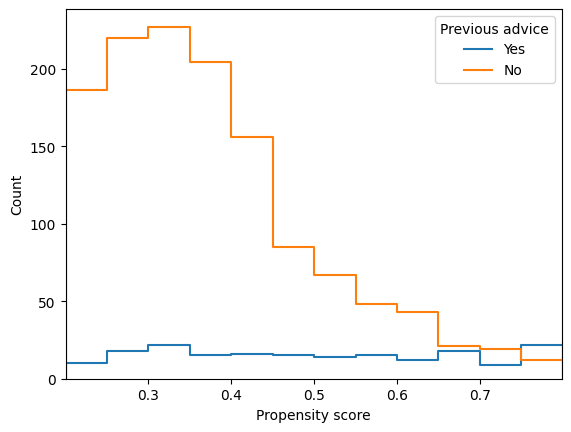

In [257]:
# Estimate and evaluate Propensity Score
estimate_propensity_score(model, class_weight={True: 5, False: 1})
evaluate_propensity_scores(model)

#### Effect estimation

In [258]:
# Estimate 
method_name = "backdoor.propensity_score_matching"
ate_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='ate',
)
print('ATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    ate_estimate.value, *ate_estimate.get_confidence_intervals())
)

ATE = 178 kg/ha, CI = -193 - 449 kg/ha


#### Refutate the estimate

placebo_treatment_refuter


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:178.08370427680006
New effect:-6.512775358725953
p value:0.9199999999999999



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:178.08370427680006
New effect:178.08370427680006
p value:1.0



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:178.08370427680006
New effect:203.000359742557
p value:0.8600000000000001



/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:366: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_data.loc[rel_interval <= w_random, treatment_name] = (


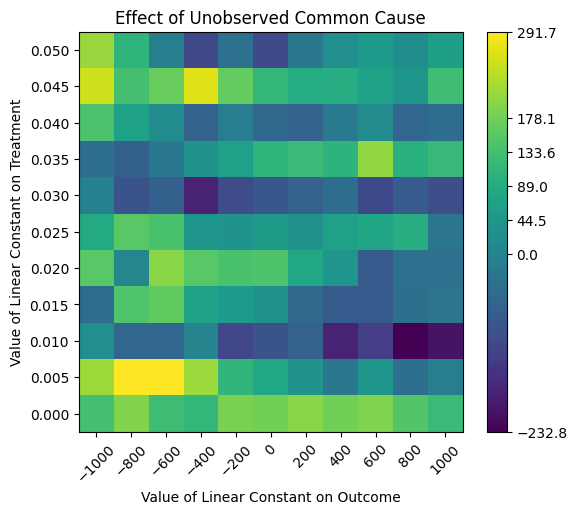

In [259]:
# Refute
def refute_estimate(estimate, model=model, identified_estimand=identified_estimand):
    print("placebo_treatment_refuter")
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="data_subset_refuter", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_unobserved_auto = model.refute_estimate(
        identified_estimand, estimate, method_name="add_unobserved_common_cause",
        confounders_effect_on_treatment="binary_flip", confounders_effect_on_outcome="linear",
        effect_strength_on_treatment=np.linspace(0, 0.05, 11), 
        effect_strength_on_outcome=np.linspace(-1000, 1000, 11)
    )
refute_estimate(ate_estimate)

### Estimate ATT

#### Propensity score estimation

              precision    recall  f1-score   support

       False       0.92      0.88      0.90      1684
        True       0.36      0.48      0.41       233

    accuracy                           0.83      1917
   macro avg       0.64      0.68      0.66      1917
weighted avg       0.86      0.83      0.84      1917

1431 samples


<Axes: xlabel='Propensity score', ylabel='Count'>

,Before Matching,After Matching
fieldsize,0.132848,0.017378
histlegume,0.361894,0.025525
wthtmean,0.213055,0.081314
srfcec,0.160829,0.137248
techhandhoe,0.208362,0.168887
wthsrad,0.258246,0.150124
wthprec,0.108972,0.085552
genderfemale,0.025084,0.056463
techtractor,0.231430,0.176905
spfoc,0.161047,0.153373


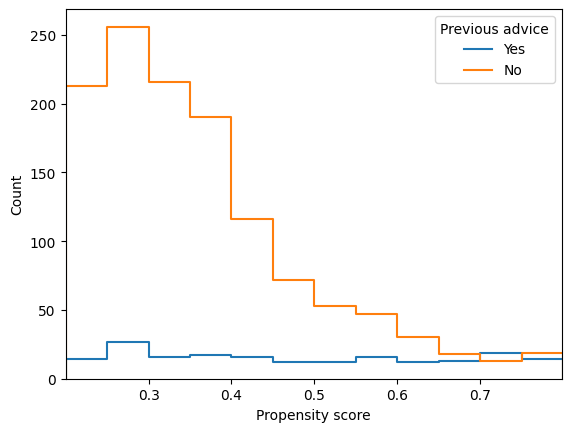

In [273]:
estimate_propensity_score(model, class_weight={True: 4.51, False: 1})
evaluate_propensity_scores(model, treat_groups=[True])

#### Effect estimation

In [274]:
att_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='att',
)
print('ATT = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    att_estimate.value, *att_estimate.get_confidence_intervals())
)

ATT = 563 kg/ha, CI = 175 - 1139 kg/ha


#### Refute the estimate

placebo_treatment_refuter


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:562.9123583893415
New effect:57.48482828756222
p value:0.72



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:562.9123583893415
New effect:562.9123583893414
p value:1.0



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:562.9123583893415
New effect:528.5696217996201
p value:0.86



/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:366: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_data.loc[rel_interval <= w_random, treatment_name] = (


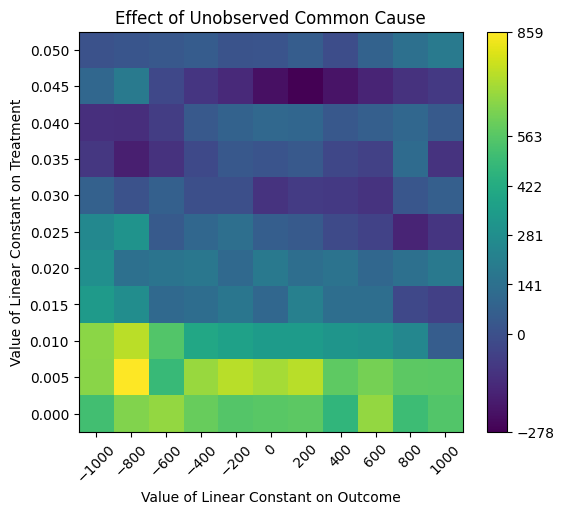

In [275]:
refute_estimate(att_estimate)

## Conclusions

No average significant average treatment effect when considering the whole sample, but there is a significant treatment effect when only considering the treated. Therefore, the advice could be working for the ones receiving it.

**The method is incredibly sensitive to the propensity score estimate**

## Causal ML effect estimate

### Double Machine Learning (DML)

DML makes the following structural equation assumptions on the data generating process:

$$
\begin{split}Y =~& \theta(X) \cdot T + g(X, W) + \epsilon ~~~&~~~ \mathbb{E}[\epsilon | X, W] = 0 \\
T =~& f(X, W) + \eta & \mathbb{E}[\eta \mid X, W] = 0 \\
~& \mathbb{E}[\eta \cdot \epsilon | X, W] = 0\end{split}
$$

What is particularly attractive about DML is that it makes no further structural assumptions on $g$ and $f$ and estimates them non-parametrically using arbitrary non-parametric Machine Learning methods. Our goal is to estimate the constant marginal CATE $\theta(X)$

In [280]:
from econml.dml import LinearDML, CausalForestDML, NonParamDML
from econml.inference import BootstrapInference
from econml.cate_interpreter import SingleTreeCateInterpreter
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor

### First stage estimators ($g$ and $f$)

The first stage estimators are the ones that predict the outcome and treatment based on the confounders and effect modifiers.

In [278]:
feature_names = identified_estimand.backdoor_variables['backdoor']
# feature_names = data_subset.drop(columns=['previousadvice', 'prodkgha']).columns
numeric_features = list(data_subset[feature_names].select_dtypes(include='number').columns)
categorical_features = list(set(feature_names) - set(numeric_features))

T = data_subset.previousadvice.values
numeric_transformer = StandardScaler().fit(data_subset[numeric_features])
X = W = np.hstack([
    numeric_transformer.transform(data_subset[numeric_features]),
    data_subset[categorical_features].values
])
Y = data_subset.prodkgha.astype(np.float32).values

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(X, Y, T, random_state=24)

In [285]:
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 500, 1000]
}
reg = RandomForestRegressor()
grid_search = GridSearchCV(reg, parameters)
grid_search.fit(X_train, y_train)
pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head()

,params,mean_test_score
7,"{'max_depth': 20, 'min_samples_split': 10}",0.189635
4,"{'max_depth': 10, 'min_samples_split': 10}",0.187702
8,"{'max_depth': 20, 'min_samples_split': 20}",0.187360
5,"{'max_depth': 10, 'min_samples_split': 20}",0.185572
3,"{'max_depth': 10, 'min_samples_split': 5}",0.184267


In [286]:
# Best: max_depth=20, min_samples_split=20
f_y = grid_search.best_estimator_
r2_score(y_true=y_test, y_pred=f_y.predict(X_test))

In [287]:
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 1000], 
    'class_weight': [{True: 1, False: 1}, {True: 3, False: 1}, {True: 5, False: 1}]
}
cls = RandomForestClassifier()
grid_search = GridSearchCV(cls, parameters, scoring='roc_auc')
grid_search.fit(X_train, t_train)
pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head()

,params,mean_test_score
24,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.866009
25,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.866002
15,"{'class_weight': {True: 3, False: 1}, 'max_dep...",0.863381
26,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.861433
16,"{'class_weight': {True: 3, False: 1}, 'max_dep...",0.861242


In [288]:
# Best: max_depth=20, min_samples_split=10, class_weight={False: 1, True: 5}
f_t = grid_search.best_estimator_
print(classification_report(y_true=t_test, y_pred=f_t.predict(X_test)))

              precision    recall  f1-score   support

       False       0.91      0.97      0.94       418
        True       0.62      0.34      0.44        62

    accuracy                           0.89       480
   macro avg       0.76      0.65      0.69       480
weighted avg       0.87      0.89      0.87       480



### LinearDML estimator

In [317]:
ldml_est = LinearDML(
    model_y=f_y, 
    model_t=f_t,
    discrete_treatment=True
)

W = pd.DataFrame(X, columns=numeric_features+categorical_features)
X_effmods = X.drop(columns=['wthsrad', 'sppsand', 'sppclay', 'srfcec', 'sppdensity', 'histoilseed'])
ldml_est.fit(
    Y=Y, T=T, X=X_effmods, W=W, inference=BootstrapInference(n_bootstrap_samples=100)
)
print('ATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    ldml_est.ate(X_effmods), *ldml_est.ate_interval(X_effmods))
)

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


ATE = 39 kg/ha, CI = -2317 - 2395 kg/ha


In [318]:
def print_cate(est, condition):
    if isinstance(condition, pd.Series):
        condition = condition.values
    print('CATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
        est.ate(X_effmods.iloc[condition]), *est.ate_interval(X_effmods.iloc[condition], alpha=.05))
    )
# ATT
print_cate(ldml_est, T==1)

CATE = 127 kg/ha, CI = -988 - 1241 kg/ha


#### Heterogeneous effects on the treated units 

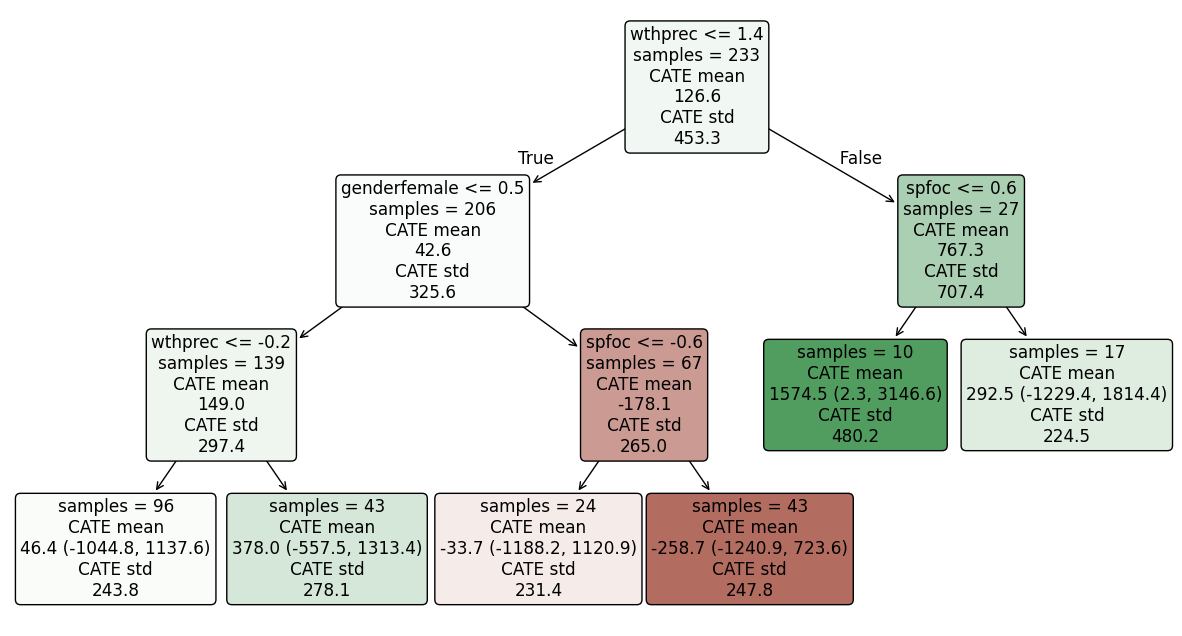

In [319]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=3, min_samples_leaf=10)
intrp.interpret(ldml_est, X_effmods[T==1])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X_effmods.columns, precision=1)

- Postive effect (2.3 - 3147 kg/ha) for units with lower fertility (soc<=0.6sd) and higher precipitation amounts (prec>1.4sd).

#### Heterogeneous effects on the untreated units 

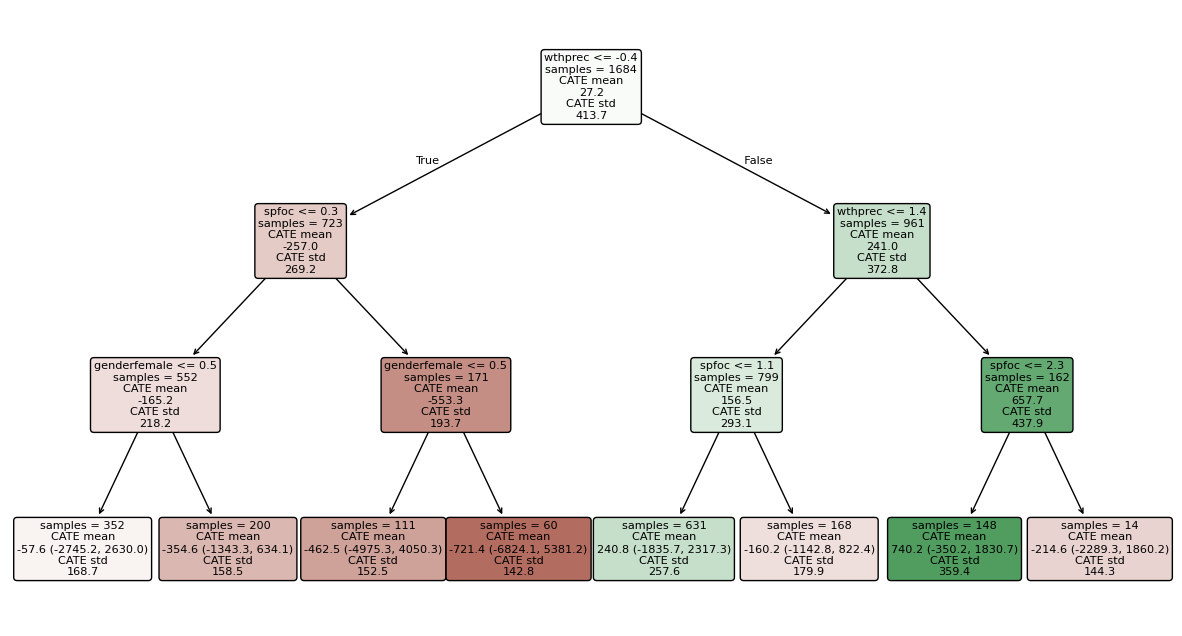

In [320]:
intrp.interpret(ldml_est, X_effmods[T==0])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X_effmods.columns, precision=1)

- Similar to previous tree. Mostly postive effect (-350 - 1830 kg/ha) for units with highest precipitation amounts (prec>1.4sd) and not-the-highest soil fertility (soc<=2.3sd)
- In this tree and the previous one gender pops up as an important effect modifier.

### Causal Forest DML Estimator

In [325]:
cf_est = CausalForestDML(
    model_t=f_t, model_y=f_y,
    criterion='het', n_estimators=500,       
    min_samples_leaf=10, max_depth=10, max_samples=0.5,
    discrete_treatment=True,
)
cf_est.fit(Y, T, X=X_effmods, W=W)

In [326]:
# ATE
print_cate(cf_est, np.ones(T.shape).astype(bool))

CATE = 168 kg/ha, CI = -776 - 1113 kg/ha


In [327]:
# ATT
print_cate(cf_est, T==1)

CATE = 174 kg/ha, CI = -856 - 1204 kg/ha


#### Heterogeneous effects on the treated units 

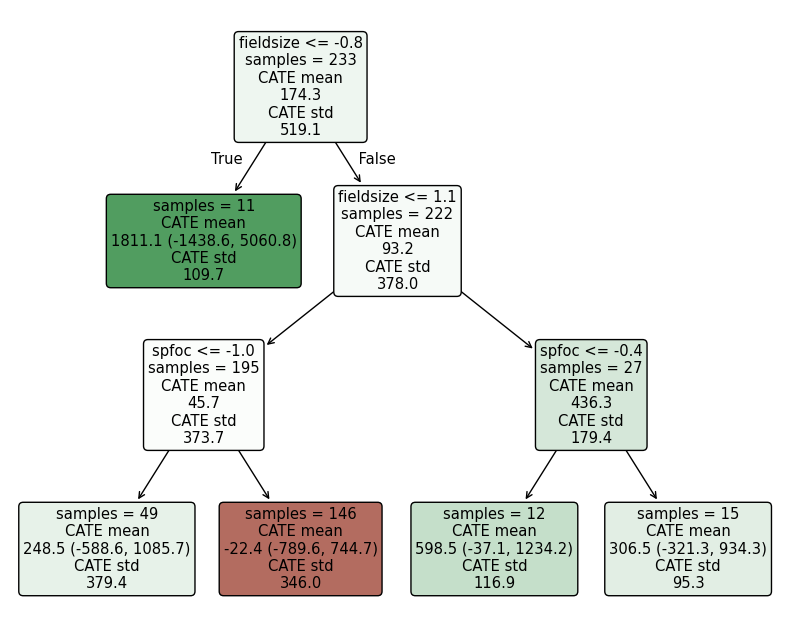

In [328]:
intrp.interpret(cf_est, X_effmods[T==1])
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
intrp.plot(feature_names=X_effmods.columns, precision=1)

- Likely postive effect on the smallest field sizes.
- Postive effect (-37 - 1234 kg/ha) on largest field sizes (size>1.1sd) with lower soil ferility (soc<=-0.4).

#### Heterogeneous effects on the untreated units 

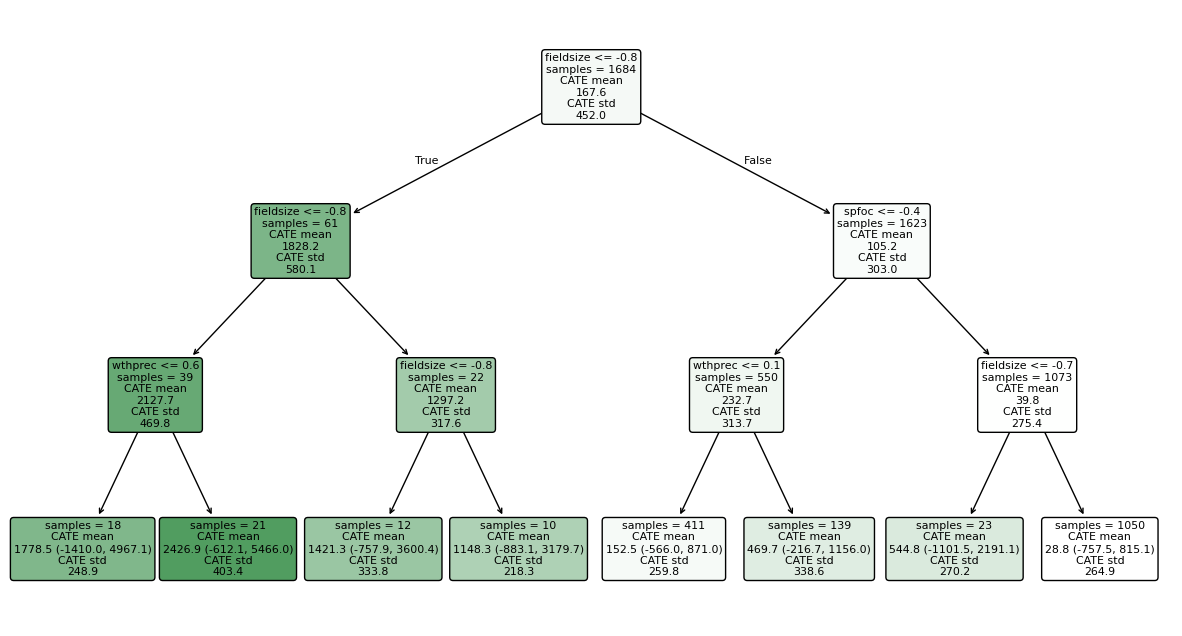

In [329]:
intrp.interpret(cf_est, X_effmods[T==0])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X_effmods.columns, precision=1)

- Likely postive effect on smaller field sizes (size<=-0.8sd).
- Mostly positive effect (-217 - 1156 kg/ha) in units with not-the-lower field sizes (size>=0.8sd), lower soil fertility (soc<=-0.4sd), and above normal precipitation amounts (prec > 0.1sd).

## Conclusions

Not a significant average effect on the treated. However, there could be a positive effect, both among the treated and untreated, that is mediated by the soil and weather. Units with lower soil fertility and higher precipitation amounts seem to have a positive treatment effect. This is backed by the two DML methods. Gender pops up as important effect modifier in the LinearDML method, suggesting more negative effects on female units. 